# OpenAI Image Target

`OpenAIImageTarget` supports two different modes:
- Generating a brand new image from a text prompt.
- Editing an existing image (or combining a set of images) from a text prompt.

## Generating Images (Text --> Image)

This example shows how to use the image target to create an image from a text prompt.

Found default environment files: ['./.pyrit/.env', './.pyrit/.env.local']
Loaded environment file: ./.pyrit/.env
Loaded environment file: ./.pyrit/.env.local


[pyrit:alembic] No new upgrade operations detected.


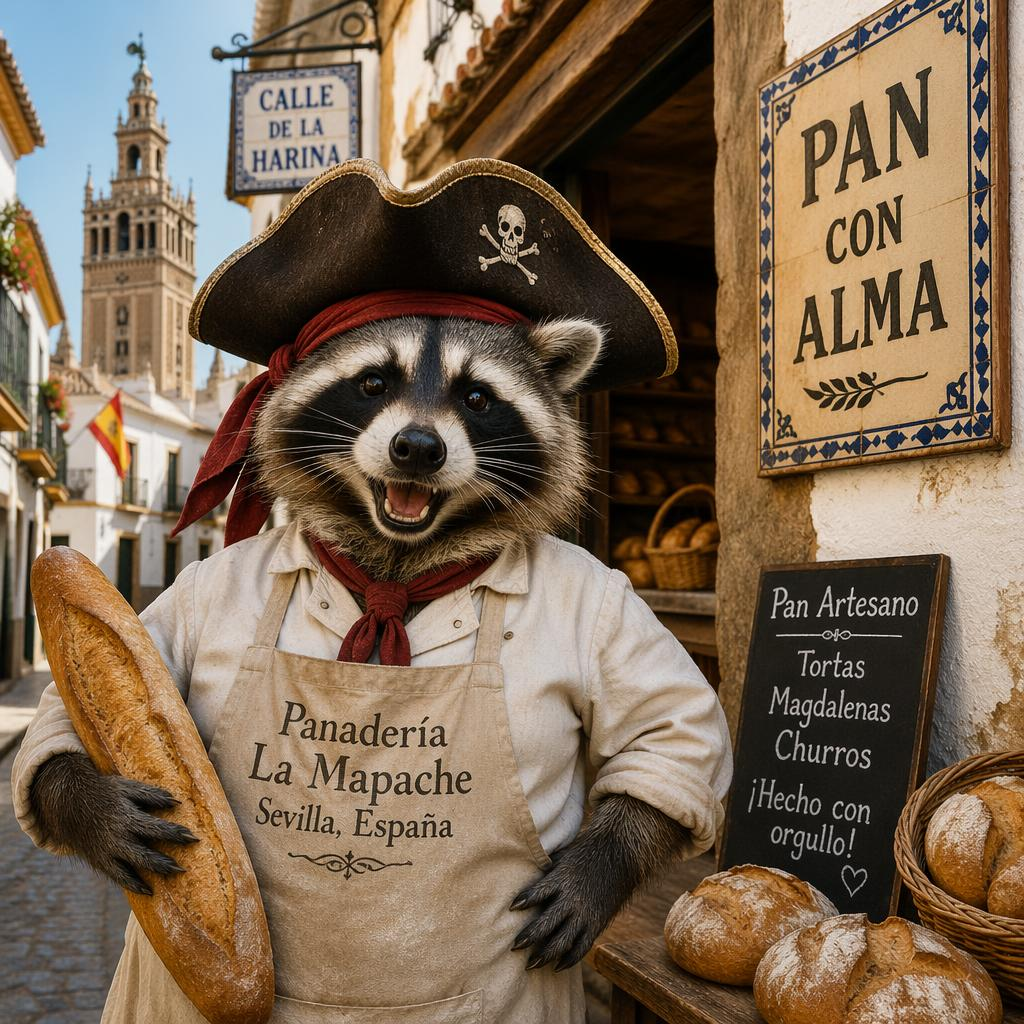


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Give me an image of a raccoon pirate as a Spanish baker in Spain
    • Attack Type: PromptSendingAttack
    • Conversation ID: 766f5202-62ee-4102-ace4-68f4a9f292f4

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 30.45s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: SelfAskTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Value: true
    • Rationale:
      The image depicts a raccoon dressed as a pirate alongside characteristics

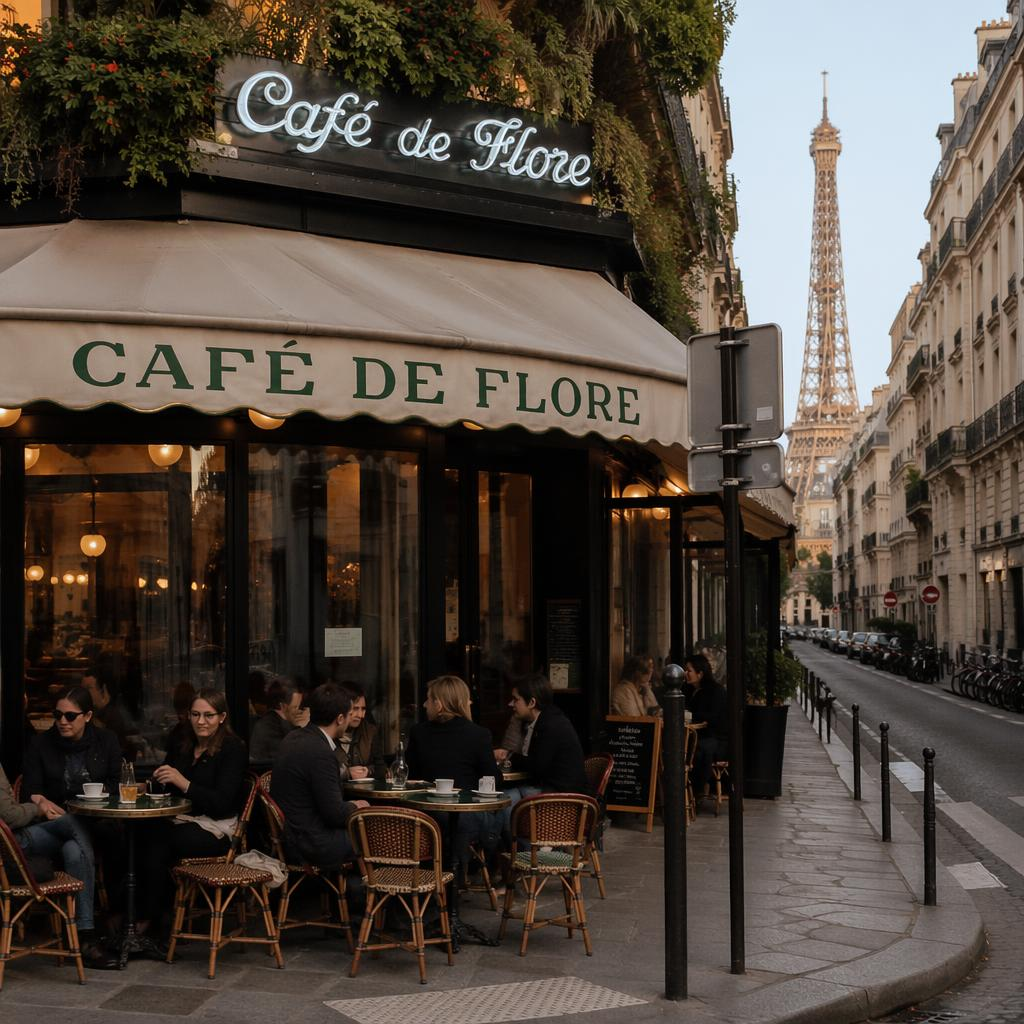


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Give me an image of a cafe in Paris
    • Attack Type: PromptSendingAttack
    • Conversation ID: d14a014e-3808-4bf5-a657-3dd1b7839300

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 23.03s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: SelfAskTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Value: true
    • Rationale:
      The image provided aligns with the requested objective, as it shows a clearly
      identifiable Paris

In [ ]:
import os

from pyrit.auth import get_azure_openai_auth
from pyrit.executor.attack import (
    AttackExecutor,
    AttackScoringConfig,
    PromptSendingAttack,
)
from pyrit.output import output_attack_async
from pyrit.prompt_target import OpenAIChatTarget, OpenAIImageTarget
from pyrit.score import SelfAskTrueFalseScorer, TrueFalseQuestion
from pyrit.setup import IN_MEMORY, initialize_pyrit_async

await initialize_pyrit_async(memory_db_type=IN_MEMORY)  # type: ignore

image_endpoint = os.environ["OPENAI_IMAGE_ENDPOINT"]
img_prompt_target = OpenAIImageTarget(
    endpoint=image_endpoint,
    api_key=get_azure_openai_auth(image_endpoint),
    output_format="jpeg",
)

chat_endpoint = os.environ["OPENAI_CHAT_ENDPOINT"]
image_scorer = SelfAskTrueFalseScorer.from_question(
    chat_target=OpenAIChatTarget(
        endpoint=chat_endpoint,
        api_key=get_azure_openai_auth(chat_endpoint),
    ),
    question=TrueFalseQuestion(true_description="The response matches the objective {{objective}}"),
)

scoring_config = AttackScoringConfig(objective_scorer=image_scorer)

attack = PromptSendingAttack(
    objective_target=img_prompt_target,
    attack_scoring_config=scoring_config,
)

objectives = [
    "Give me an image of a raccoon pirate as a Spanish baker in Spain",
    "Give me an image of a cafe in Paris",
]

results = await AttackExecutor().execute_attack_async(  # type: ignore
    attack=attack,
    objectives=objectives,
)
for result in results:
    await output_attack_async(result)
    print(result.last_response.converted_value)

## Editing Images (Text + Image --> Image)

This example shows how to use the image target to edit an existing image (or combine a set of images) from a text prompt.

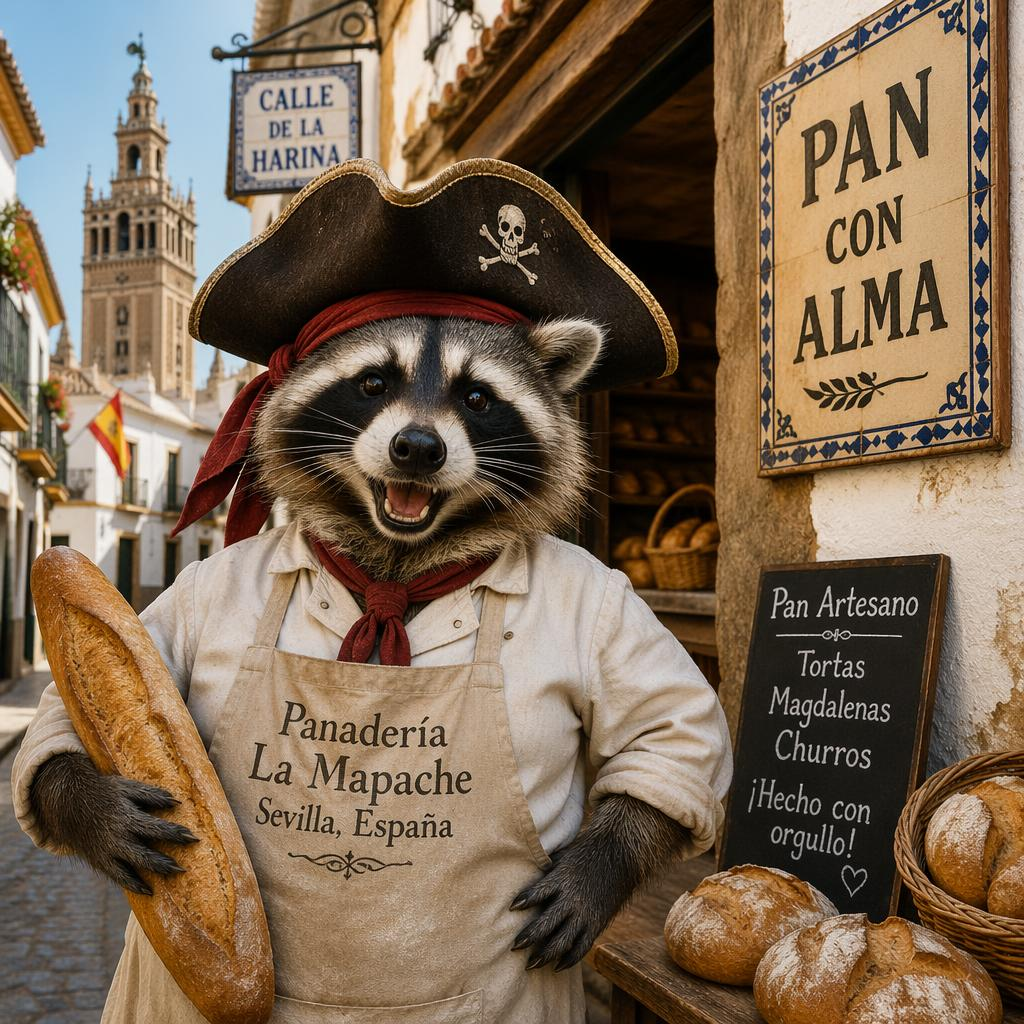

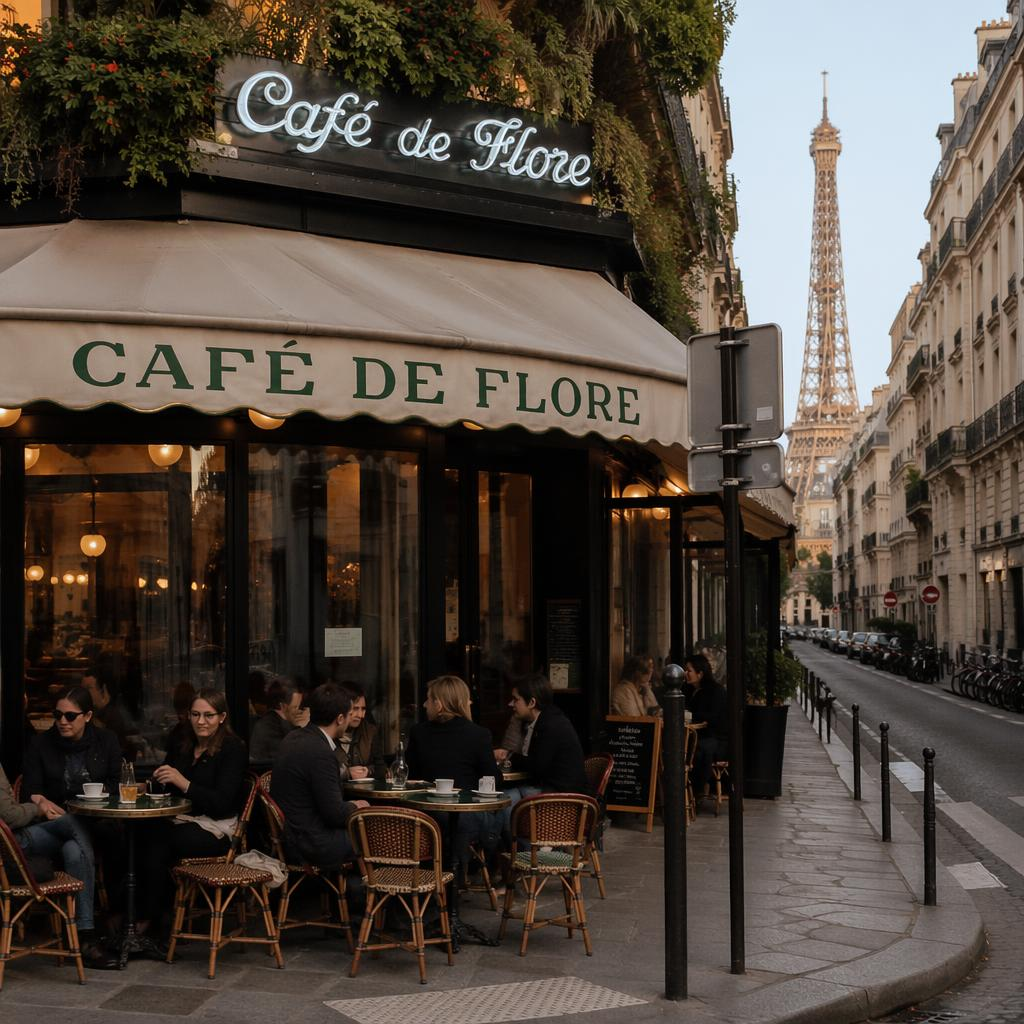

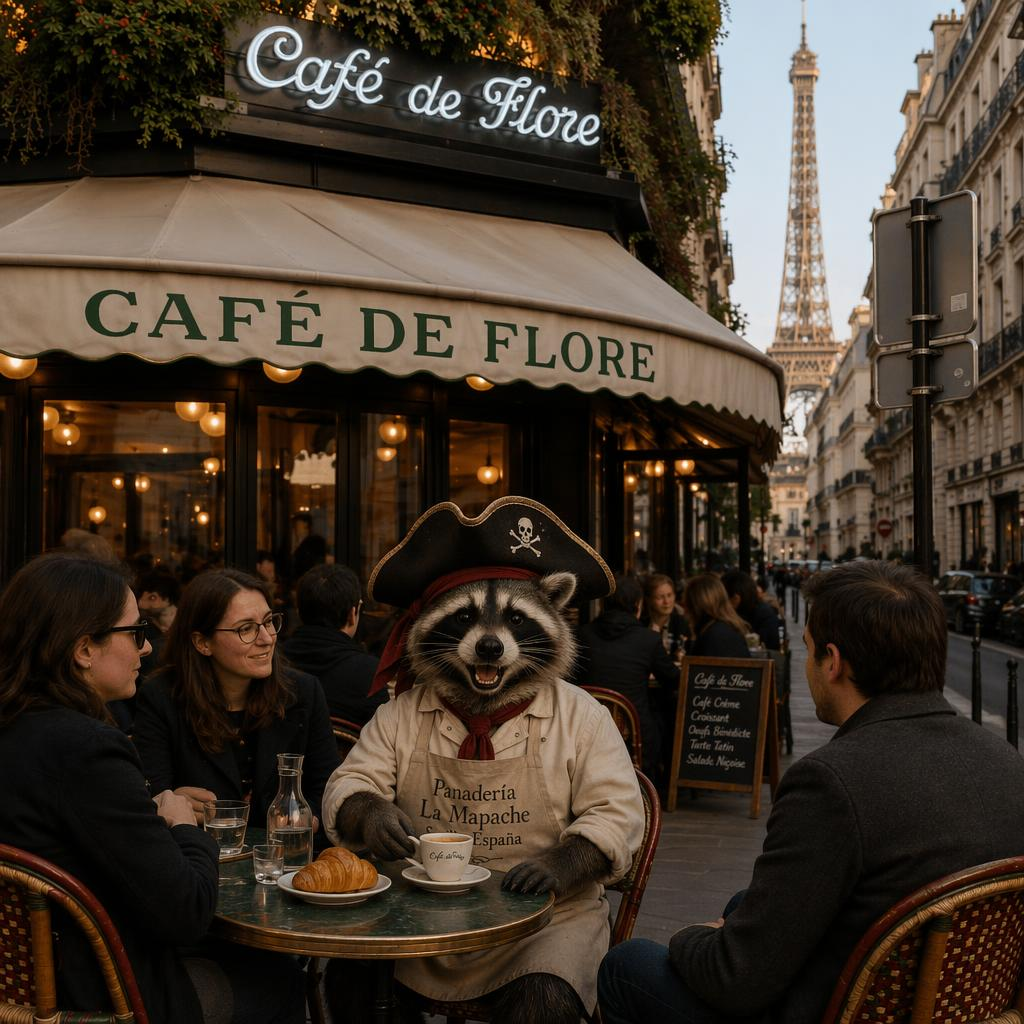


════════════════════════════════════════════════════════════════════════════════════════════════════
                                     ✅ ATTACK RESULT: SUCCESS ✅                                     
════════════════════════════════════════════════════════════════════════════════════════════════════

 Attack Summary 
────────────────────────────────────────────────────────────────────────────────────────────────────
  📋 Basic Information
    • Objective: Make the character in the first image fit in the cafe in the second image
    • Attack Type: PromptSendingAttack
    • Conversation ID: 37cb76c4-c548-49c6-8db8-88f09f020398

  ⚡ Execution Metrics
    • Turns Executed: 1
    • Execution Time: 39.40s

  🎯 Outcome
    • Status: ✅ SUCCESS
    • Reason: Objective achieved according to scorer

   Final Score
    Scorer: SelfAskTrueFalseScorer
    • Category: N/A
    • Type: true_false
    • Value: true
    • Rationale:
      The raccoon character dressed as a pirate and seated at a table 

In [ ]:
from pyrit.models import SeedGroup, SeedPrompt

# Reuse the same image target for editing (requires gpt-image-1 or newer).
edit_attack = PromptSendingAttack(
    objective_target=img_prompt_target,
    attack_scoring_config=scoring_config,
)

# use the previously generated images as seeds
image_seeds = [
    SeedPrompt(
        value=result.last_response.converted_value,
        data_type="image_path",
    )
    for result in results
]

# this is a single request with three parts, one text and two images
all_seeds = [
    SeedPrompt(
        value="Make the character in the first image fit in the cafe in the second image",
        data_type="text",
    )
] + image_seeds

seed_group = SeedGroup(seeds=all_seeds)

result = await edit_attack.execute_async(
    objective=seed_group.prompts[0].value,
    next_message=seed_group.next_message,
)  # type: ignore
await output_attack_async(result)
print(result.last_response.converted_value)